<a href="https://colab.research.google.com/github/sdplamen/Decoding-F-Stop_Mathematical-concepts-in-Photography/blob/main/Decoding_the_F_Stop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decoding the f-stop (The Hidden Mathematics of Photography)

---

## Introduction

Every camera in the world shares the same mysterious sequence of numbers on its aperture dial:

$$f/1.4, \quad f/2, \quad f/2.8, \quad f/4, \quad f/5.6, \quad f/8, \quad f/11, \quad f/16$$

Most photographers memorize this sequence without ever asking: *why these numbers?* Why not f/1, f/2, f/3, f/4? Why does the sequence jump by seemingly irregular amounts?

The answer is pure mathematics — and it connects geometry, calculus, linear algebra, probability, and logic in one of the most elegant applied math stories in everyday life.

In this project we will:
- **Derive** the f-stop sequence from first principles using geometry
- **Model** the exposure triangle as a linear system in log-space
- **Optimize** exposure settings using calculus and gradient descent
- **Simulate** how cameras meter light using probability and statistics


**[Sources: Camera Exposure](https://www.cambridgeincolour.com/tutorials/camera-exposure.htm)**

## 1. The f-stop Sequence: Where Does √2 Come From?

### 1. 1. What is an f-stop?

The **f-number** (or f-stop) is defined as:

$$f\text{-number} = \frac{f}{D}$$

where $f$ is the **focal length** of the lens and $D$ is the **diameter of the aperture** (the opening that lets light in).

So f/2 means the aperture diameter is half the focal length. f/8 means the aperture is one-eighth the focal length — a much smaller opening.

Notice something immediately: **a larger f-number means a smaller aperture**. This is the first counterintuitive thing photographers learn.
**[Sources: F-Number](https://en.wikipedia.org/wiki/F-number)**

### 1. 2. Why $ \sqrt 2 $? The Geometry of Light

The amount of light reaching the sensor depends not on the diameter of the aperture, but on its **area**:

$$A = \pi \left(\frac{D}{2}\right)^2 = \frac{\pi D^2}{4}$$

Photographers define one **stop** as a factor of **2× in light** — either doubling or halving it. So the question becomes: by what factor must we multiply the diameter $D$ to double the area $A$?

$$2A = \frac{\pi (D \cdot x)^2}{4} \implies 2 = x^2 \implies x = \sqrt{2}$$

**[Sources: Lens Aperture](https://www.cambridgeincolour.com/tutorials/lens-aperture.htm)**

**Each stop requires multiplying the aperture diameter by $\sqrt{2} \approx 1.414$.**

Since $f\text{-number} = f/D$, and $D$ increases by $\sqrt{2}$ per stop, the f-number sequence is generated by **multiplying by $\sqrt{2}$ repeatedly** starting from f/1:

$$1, \; \sqrt{2}, \; 2, \; 2\sqrt{2}, \; 4, \; 4\sqrt{2}, \; 8, \ldots$$

Which rounds to: **1.0, 1.4, 2.0, 2.8, 4.0, 5.6, 8.0, 11, 16, 22...**

**[Sources: APEX Systems](https://en.wikipedia.org/wiki/APEX_system)**

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Pyplot style colors
GOLD   = '#f5c842'
TEAL   = '#42c5f5'
CORAL  = '#f57842'
GREEN  = '#72f542'
PURPLE = '#a142f5'

*Generate the f-stop sequence from first principles*
- Generate f-stop values by repeatedly multiplying by $ \sqrt{2} $.

In [8]:
def generate_fstop_sequence(n_stops=12, start=1.0):
    return [start * (np.sqrt(2) ** i) for i in range(n_stops)]

fstops = generate_fstop_sequence(12)
standard = [1, 1.4, 2, 2.8, 4, 5.6, 8, 11, 16, 22, 32, 45]

print("f-stop sequence (derived):")
print("  " + "  ".join([f"f/{v:.2f}" for v in fstops]))
print("\nStandard camera markings:")
print("  " + "  ".join([f"f/{v}" for v in standard]))
print("\nDifference (rounding error):")
print("  " + "  ".join([f"{abs(a-b):.4f}" for a, b in zip(fstops, standard)]))

f-stop sequence (derived):
  f/1.00  f/1.41  f/2.00  f/2.83  f/4.00  f/5.66  f/8.00  f/11.31  f/16.00  f/22.63  f/32.00  f/45.25

Standard camera markings:
  f/1  f/1.4  f/2  f/2.8  f/4  f/5.6  f/8  f/11  f/16  f/22  f/32  f/45

Difference (rounding error):
  0.0000  0.0142  0.0000  0.0284  0.0000  0.0569  0.0000  0.3137  0.0000  0.6274  0.0000  0.2548


### 1. 3. Half-Stops and Third-Stops

Modern cameras also offer **half-stop** and **third-stop** increments for finer control. These are generated by the same logic:

- **Half-stop**: multiply by $2^{1/4} = \sqrt{\sqrt{2}}$
- **Third-stop**: multiply by $2^{1/6}$

*Visualize aperture area vs f-stop*
- Plot 1: Aperture circles to scale.
- Plot 2: Area halving with each stop.

In [9]:
def fstop_sequence(divisions_per_stop=1, n_stops=6, start=1.0):
    factor = 2 ** (1 / (2 * divisions_per_stop))
    n = n_stops * divisions_per_stop + 1
    return [round(start * factor ** i, 2) for i in range(n)]

full   = fstop_sequence(1)
half   = fstop_sequence(2)
third  = fstop_sequence(3)

print(f"Full stops  ({len(full)} values):  " + "  ".join([f"f/{v}" for v in full]))
print(f"Half stops  ({len(half)} values): " + "  ".join([f"f/{v}" for v in half]))
print(f"Third stops ({len(third)} values): " + "  ".join([f"f/{v}" for v in third]))

Full stops  (7 values):  f/1.0  f/1.41  f/2.0  f/2.83  f/4.0  f/5.66  f/8.0
Half stops  (13 values): f/1.0  f/1.19  f/1.41  f/1.68  f/2.0  f/2.38  f/2.83  f/3.36  f/4.0  f/4.76  f/5.66  f/6.73  f/8.0
Third stops (19 values): f/1.0  f/1.12  f/1.26  f/1.41  f/1.59  f/1.78  f/2.0  f/2.24  f/2.52  f/2.83  f/3.17  f/3.56  f/4.0  f/4.49  f/5.04  f/5.66  f/6.35  f/7.13  f/8.0


*Visualize aperture area vs f-stop*
- Generate f-stop sequence with fractional stop divisions.

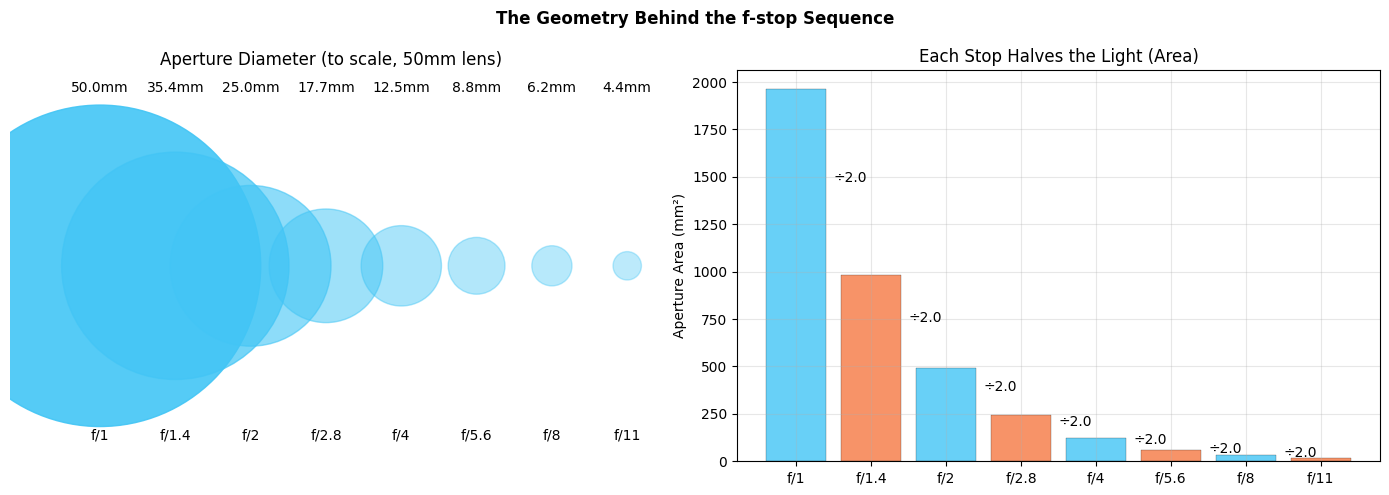


Area ratios between consecutive stops:
  f/1 → f/1.4: area ratio = 2.0000 (should be ~2.0)
  f/1.4 → f/2: area ratio = 2.0000 (should be ~2.0)
  f/2 → f/2.8: area ratio = 2.0000 (should be ~2.0)
  f/2.8 → f/4: area ratio = 2.0000 (should be ~2.0)
  f/4 → f/5.6: area ratio = 2.0000 (should be ~2.0)
  f/5.6 → f/8: area ratio = 2.0000 (should be ~2.0)
  f/8 → f/11: area ratio = 2.0000 (should be ~2.0)


In [10]:
focal_length = 50
diameters = [focal_length / f for f in fstops[:8]]
areas = [np.pi * (d/2)**2 for d in diameters]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('The Geometry Behind the f-stop Sequence', fontweight='bold')

ax = axes[0]
ax.set_xlim(-1, 9)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.set_title('Aperture Diameter (to scale, 50mm lens)')
ax.axis('off')

positions = np.linspace(0.4, 8.6, 8)
max_d = diameters[0]
for i, (pos, d, f) in enumerate(zip(positions, diameters, fstops[:8])):
    radius = (d / max_d) * 2.5
    alpha = 0.3 + 0.6 * (d / max_d)
    circle = plt.Circle((pos, 0), radius, color=TEAL, alpha=alpha)
    ax.add_patch(circle)
    ax.text(pos, -2.7, f'f/{standard[i]}', ha='center')
    ax.text(pos, 2.7, f'{d:.1f}mm', ha='center')

ax2 = axes[1]
bars = ax2.bar(range(8), areas, color=[TEAL if i % 2 == 0 else CORAL for i in range(8)], alpha=0.8, edgecolor='black', linewidth=0.2)
ax2.set_xticks(range(8))
ax2.set_xticklabels([f'f/{standard[i]}' for i in range(8)])
ax2.set_ylabel('Aperture Area (mm²)')
ax2.set_title('Each Stop Halves the Light (Area)')
ax2.grid(True, alpha=0.3)

for i in range(1, 8):
    ratio = areas[i-1] / areas[i]
    ax2.annotate(f'÷{ratio:.1f}', xy=(i-0.5, (areas[i-1]+areas[i])/2))

plt.tight_layout()
plt.show()

print("\nArea ratios between consecutive stops:")
for i in range(1, 8):
    print(f"  f/{standard[i-1]} → f/{standard[i]}: area ratio = {areas[i-1]/areas[i]:.4f} (should be ~2.0)")

## 2. The Exposure Equation in Log-Space

### 2. 1. The Exposure Triangle

A photograph's exposure depends on three variables:

| Variable | Symbol | Effect |
|---|---|---|
| Aperture (f-number) | $N$ | Controls depth of field & light |
| Shutter Speed | $t$ | Controls motion blur & light |
| Sensor Sensitivity | $S$ (ISO) | Controls noise & light |

The **Exposure Value (EV)** unifies all three into a single number:

$$EV = \log_2\left(\frac{N^2}{t}\right)$$

And when ISO is factored in, the **effective EV** at a given scene luminance $L$ is:

$$EV_{100} = \log_2\left(\frac{L \cdot S}{K}\right)$$

where $K \approx 12.5$ is the reflected-light meter calibration constant and $S$ is ISO.

**[Sources: Camera Metering](https://www.cambridgeincolour.com/tutorials/camera-metering.htm)**

### 2. 2. Why Log-Space Makes Everything Linear

Taking $\log_2$ of the exposure equation:

$$EV = 2\log_2(N) - \log_2(t)$$

This is a **linear equation** in log-space! We can write the entire exposure triangle as:

$$EV = 2\log_2(N) - \log_2(t) - \log_2(S/100)$$

Let $a = \log_2(N)$, $b = \log_2(t)$, $c = \log_2(S/100)$. Then:

$$EV = 2a - b - c$$

**[Sources: Linear Algebra](https://ocw.mit.edu/courses/18-06-linear-algebra-spring-2010/)**

In matrix form: $\mathbf{w}^T \mathbf{x} = EV$ where $\mathbf{w} = [2, -1, -1]$ and $\mathbf{x} = [a, b, c]^T$.

This means all valid exposure combinations for a given EV lie on a **hyperplane in log-space** — a fundamentally linear algebra insight.

**[Sources: APEX Systems](https://ocw.mit.edu/courses/18-06-linear-algebra-spring-2010/)**

### 2. 3. The Sunny 16 Rule — A Linear Algebra Verification

Photographers use the famous **Sunny 16 Rule**: on a bright sunny day, set aperture to f/16 and shutter speed to 1/ISO.

**[Sources: Sunny 16 rule](https://en.wikipedia.org/wiki/Sunny_16_rule)**

*EV calculation and the solution hyperplane*
- Compute Exposure Value from aperture (f-number), shutter (seconds), ISO.
- Convert EV to scene luminance (cd/m²).

In [11]:
def compute_ev(aperture, shutter, iso=100):
    return 2 * np.log2(aperture) - np.log2(shutter) - np.log2(iso / 100)

def ev_to_luminance(ev, iso=100, K=12.5):
    return (2 ** ev * K) / iso

ev_descriptions = {
    -6: 'Night, no moon',
    -1: 'Candle at 1m',
     3: 'Indoor, dim',
     6: 'Indoor, bright',
     9: 'Overcast outdoors',
    12: 'Bright overcast',
    15: 'Sunny day (Sunny 16)',
    17: 'Snow / beach in sun',
}

print("Exposure Value Reference Table")
print(f"{'EV':5} | {'Scene':25} | {'Luminance (cd/m²)':20}")
print("-" * 58)
for ev, desc in ev_descriptions.items():
    lum = ev_to_luminance(ev)
    print(f"{ev:5} | {desc:25} | {lum:20.3f}")

Exposure Value Reference Table
EV    | Scene                     | Luminance (cd/m²)   
----------------------------------------------------------
   -6 | Night, no moon            |                0.002
   -1 | Candle at 1m              |                0.062
    3 | Indoor, dim               |                1.000
    6 | Indoor, bright            |                8.000
    9 | Overcast outdoors         |               64.000
   12 | Bright overcast           |              512.000
   15 | Sunny day (Sunny 16)      |             4096.000
   17 | Snow / beach in sun       |            16384.000


*Visualize the solution space (hyperplane) for a given EV*

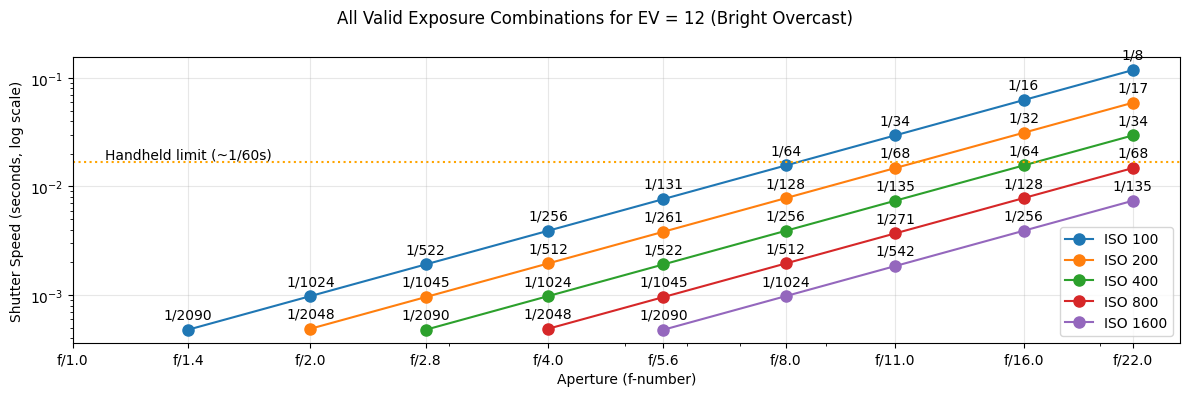


Key insight: All these combinations produce the SAME exposure (same EV).
They differ in: depth of field (aperture), motion blur (shutter), noise (ISO).


In [12]:
target_ev = 12
iso_values = [100, 200, 400, 800, 1600, 3200]

apertures = np.array([1, 1.4, 2, 2.8, 4, 5.6, 8, 11, 16, 22])

fig, ax = plt.subplots(figsize=(12, 4))
fig.suptitle(f'All Valid Exposure Combinations for EV = {target_ev} (Bright Overcast)')

colors = [TEAL, GOLD, CORAL, GREEN, PURPLE]
for iso, color in zip(iso_values, colors):
    shutters = []
    valid_apertures = []
    for n in apertures:
        log_t = 2 * np.log2(n) - np.log2(iso/100) - target_ev
        t = 2 ** log_t
        if 1/4000 <= t <= 30:
            shutters.append(t)
            valid_apertures.append(n)

    ax.plot(valid_apertures, shutters, 'o-',
            markersize=8, label=f'ISO {iso}')
    for n, t in zip(valid_apertures, shutters):
        if t >= 1:
            label = f'{t:.0f}"'
        elif t >= 0.1:
            label = f'1/{int(round(1/t))}'
        else:
            label = f'1/{int(round(1/t))}'
        ax.annotate(label, (n, t), textcoords='offset points',
                   xytext=(0, 8), ha='center')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xticks(apertures)
ax.set_xticklabels([f'f/{n}' for n in apertures])
ax.set_ylabel('Shutter Speed (seconds, log scale)')
ax.set_xlabel('Aperture (f-number)')
ax.legend()
ax.grid(True, alpha=0.3)


ax.axhline(y=1/60, color='orange', linestyle=':')
ax.text(1.1, 1/55, 'Handheld limit (~1/60s)')

plt.tight_layout()
plt.show()

print("\nKey insight: All these combinations produce the SAME exposure (same EV).\nThey differ in: depth of field (aperture), motion blur (shutter), noise (ISO).")

*Verifying the Sunny 16 Rule*

In [13]:
print("Sunny 16 Rule Verification\nRule: aperture=f/16, shutter=1/ISO\n")


for iso in [100, 200, 400, 800, 1600]:
    shutter = 1 / iso
    ev = compute_ev(aperture=16, shutter=shutter, iso=iso)
    print(f"  ISO {iso:>4}: f/16, 1/{iso}s  →  EV = {ev:.2f}  (target: 15.0)")


print("\nThe Sunny 16 rule always yields EV ≈ 15, consistent across all ISO values.\nThis is because increasing ISO by 1 stop is exactly cancelled by decreasing shutter time by 1 stop — a direct consequence of the linear structure.")

Sunny 16 Rule Verification
Rule: aperture=f/16, shutter=1/ISO

  ISO  100: f/16, 1/100s  →  EV = 14.64  (target: 15.0)
  ISO  200: f/16, 1/200s  →  EV = 14.64  (target: 15.0)
  ISO  400: f/16, 1/400s  →  EV = 14.64  (target: 15.0)
  ISO  800: f/16, 1/800s  →  EV = 14.64  (target: 15.0)
  ISO 1600: f/16, 1/1600s  →  EV = 14.64  (target: 15.0)

The Sunny 16 rule always yields EV ≈ 15, consistent across all ISO values.
This is because increasing ISO by 1 stop is exactly cancelled by decreasing shutter time by 1 stop — a direct consequence of the linear structure.


## 3. Calculus of Light: Optimizing Exposure

### 3. 1. The Exposure as a Continuous Function

Let's treat exposure as a **continuous optimization problem**. Given:
- A target EV (from scene metering)
- Constraints (max ISO, min/max shutter, creative aperture preference)

To find the optimal settings, let's define a **cost function** that penalizes:
1. Deviation from target EV
2. High ISO (noise penalty)
3. Slow shutter (motion blur penalty)
4. Deviation from a preferred aperture (depth of field)

$$\mathcal{L}(N, t, S) = \underbrace{\lambda_1 (EV(N,t,S) - EV^*)^2}_{\text{exposure error}} + \underbrace{\lambda_2 \log_2(S/100)^2}_{\text{ISO penalty}} + \underbrace{\lambda_3 \max(0, t_{\min} - t)^2}_{\text{shutter penalty}} + \underbrace{\lambda_4 (N - N^*)^2}_{\text{aperture preference}}$$

**[Sources: Gradient Descent](https://www.ruder.io/optimizing-gradient-descent/)**

*Cost function and gradient descent optimizer*
- Cost function over log-space parameters.
- Compute gradient using central finite differences.
- Finding optimal exposure settings using gradient descent in log-space.

In [14]:
def cost_function(params, target_ev, preferred_aperture=5.6,
                  lambda1=10.0, lambda2=0.5, lambda3=2.0, lambda4=0.3,
                  min_shutter=1/60):
    log_n, log_t, log_s = params
    N = 2 ** log_n
    t = 2 ** log_t
    S = 100 * (2 ** log_s)

    ev = compute_ev(N, t, S)

    ev_error    = lambda1 * (ev - target_ev) ** 2
    iso_penalty = lambda2 * log_s ** 2
    shutter_pen = lambda3 * max(0, np.log2(min_shutter) - log_t) ** 2
    ap_pref     = lambda4 * (N - preferred_aperture) ** 2

    return ev_error + iso_penalty + shutter_pen + ap_pref


def numerical_gradient(f, params, h=1e-5):
    grad = np.zeros_like(params)
    for i in range(len(params)):
        p_plus  = params.copy(); p_plus[i]  += h
        p_minus = params.copy(); p_minus[i] -= h
        grad[i] = (f(p_plus) - f(p_minus)) / (2 * h)
    return grad


def gradient_descent_exposure(target_ev, preferred_aperture=5.6,
                               lr=0.05, n_iter=500, verbose=True, **kwargs):
    params = np.array([np.log2(preferred_aperture), np.log2(1/125), 0.0])

    loss_history = []
    f = lambda p: cost_function(p, target_ev, preferred_aperture, **kwargs)

    for i in range(n_iter):
        loss = f(params)
        loss_history.append(loss)
        grad = numerical_gradient(f, params)
        params -= lr * grad

        params[0] = np.clip(params[0], np.log2(1.0), np.log2(22))
        params[1] = np.clip(params[1], np.log2(1/4000), np.log2(30))
        params[2] = np.clip(params[2], 0, np.log2(102400/100))

    N_opt = 2 ** params[0]
    t_opt = 2 ** params[1]
    S_opt = 100 * (2 ** params[2])
    ev_opt = compute_ev(N_opt, t_opt, S_opt)

    if verbose:
        print(f"Gradient Descent Result")
        print(f"Target EV:      {target_ev:.1f}")
        print(f"Achieved EV:    {ev_opt:.3f}")
        print(f"Aperture:       f/{N_opt:.1f}")
        shutter_label = f'{t_opt:.0f}"' if t_opt >= 1 else f'1/{int(round(1/t_opt))}s'
        print(f"Shutter speed:  {shutter_label}")
        print(f"ISO:            {int(round(S_opt))}")
        print(f"Final loss:     {loss_history[-1]:.6f}")

    return N_opt, t_opt, S_opt, loss_history

N_opt, t_opt, S_opt, losses = gradient_descent_exposure(
    target_ev=12, preferred_aperture=5.6
)

Gradient Descent Result
Target EV:      12.0
Achieved EV:    -7.015
Aperture:       f/1.0
Shutter speed:  1/4s
ISO:            47266
Final loss:     943.478001


*Visualize gradient descent convergence*

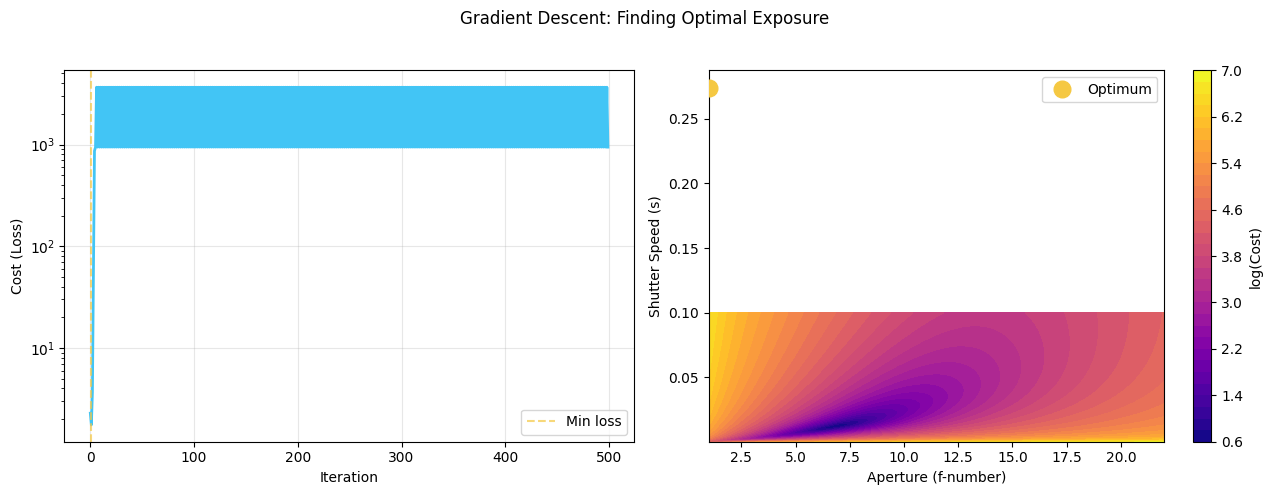

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gradient Descent: Finding Optimal Exposure')

# Loss curve
axes[0].plot(losses, color=TEAL, linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost (Loss)')
axes[0].set_title('Loss Convergence', color='white')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=np.argmin(losses), color=GOLD, linestyle='--', alpha=0.7, label='Min loss')
axes[0].legend()

N_range = np.linspace(1, 22, 100)
t_range = np.linspace(1/4000, 1/10, 100)
NN, TT = np.meshgrid(N_range, t_range)

target_ev = 12
iso_fixed = 100
cost_surface = np.array([
    [cost_function([np.log2(n), np.log2(t), 0.0], target_ev, 5.6)
     for n in N_range]
    for t in t_range
])

im = axes[1].contourf(NN, TT, np.log1p(cost_surface), levels=40, cmap='plasma')
axes[1].plot(N_opt, t_opt, 'o', color=GOLD, markersize=12, label='Optimum', zorder=5)
axes[1].set_xlabel('Aperture (f-number)')
axes[1].set_ylabel('Shutter Speed (s)')
axes[1].set_title('Cost Surface (ISO 100 fixed, log scale)', color='white')
axes[1].legend(fontsize=10)
plt.colorbar(im, ax=axes[1], label='log(Cost)')

plt.tight_layout()
plt.show()

---

## 4. Statistics of a Scene: How Cameras Meter Light

### 4. 1. Scene Luminance as a Probability Distribution

A camera's light meter doesn't see a single brightness value — it sees a **distribution** of luminance values across the frame. Different pixels have different brightnesses, and the metering strategy determines which statistic of this distribution to trust.

Natural scene luminance is approximately **log-normally distributed** — most scenes have a few very bright highlights and many mid-tones, with fewer deep shadows.

**[Sources: Normal Distribution](https://en.wikipedia.org/wiki/Log-normal_distribution)**

### 4. 2. The Three Metering Modes as Statistical Estimators

| Metering Mode | Mathematical Operation | Best For |
|---|---|---|
| **Evaluative / Matrix** | Weighted mean across zones | General scenes |
| **Center-weighted** | Gaussian-weighted mean | Portraits |
| **Spot** | Value at center pixel (mode) | High contrast scenes |

**[Sources: Camera Metering & Exposure](https://www.cambridgeincolour.com/tutorials/camera-metering.htm)**

**[Sources: Gaussian filter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter.html)**

### 4. 3. The 18% Gray Standard & Why It Exists

All light meters are calibrated to expose for **18% reflectance gray** — the statistical middle of the luminance distribution in log-space. This comes from the observation that the geometric mean of a typical scene's luminance (in linear space) corresponds to roughly 18% reflectance.

Mathematically, if luminance $L$ is log-normally distributed:

$$\ln L \sim \mathcal{N}(\mu, \sigma^2)$$

Then the geometric mean is $e^\mu$, and empirically this corresponds to ~18% of maximum white.

**[Sources: Gray card](https://en.wikipedia.org/wiki/Gray_card)**

**[Sources: The 18% Gray Myth](https://luminous-landscape.com/understanding-histograms/)**

*Simulate a scene luminance distribution*
- Simulate a scene as a 2D luminance map.
- Create a center-weighted Gaussian mask.
- Apply a metering mode to a luminance map.


In [48]:
np.random.seed(42)

def simulate_scene(scene_type='mixed', size=(100, 100)):
    H, W = size
    x = np.linspace(-1, 1, W)
    y = np.linspace(-1, 1, H)
    X, Y = np.meshgrid(x, y)

    if scene_type == 'portrait':
        base = 9 + np.random.normal(0, 0.5, size)
        subject = 12 * np.exp(-(X**2 + Y**2) / 0.15)
        return base + subject
    elif scene_type == 'backlit':
        base = 14 + np.random.normal(0, 0.3, size)
        subject = -6 * np.exp(-(X**2 + Y**2) / 0.1)
        return base + subject
    else:
        base = 11 + np.random.normal(0, 1.5, size)
        gradient = 2 * X
        return base + gradient


def gaussian_weight_map(size):
    H, W = size
    y = np.linspace(-1, 1, H)
    x = np.linspace(-1, 1, W)
    X, Y = np.meshgrid(x, y)
    sigma = 0.4
    weights = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    return weights / weights.sum()


def meter_scene(luminance_map, mode='evaluative'):
    H, W = luminance_map.shape
    cx, cy = H // 2, W // 2

    if mode == 'evaluative':
        return np.mean(luminance_map)

    elif mode == 'center_weighted':
        weights = gaussian_weight_map(luminance_map.shape)
        return np.sum(weights * luminance_map)

    elif mode == 'spot':
        r = max(H, W) // 14
        patch = luminance_map[cx-r:cx+r, cy-r:cy+r]
        return np.mean(patch)


scenes = {
    'Portrait (subject in center)': simulate_scene('portrait'),
    'Backlit (bright background)':  simulate_scene('backlit'),
    'Mixed scene':                   simulate_scene('mixed'),
}

modes = ['evaluative', 'center_weighted', 'spot']

print("Metering Mode Comparison")
print(f"{'Scene':35} | {'Evaluative':12} | {'Center-Wtd':12} | {'Spot':8}")
print("-" * 75)
for scene_name, lum_map in scenes.items():
    evs = [meter_scene(lum_map, m) for m in modes]
    print(f"{scene_name:35} | {evs[0]:12.2f} | {evs[1]:12.2f} | {evs[2]:8.2f}")

Metering Mode Comparison
Scene                               | Evaluative   | Center-Wtd   | Spot    
---------------------------------------------------------------------------
Portrait (subject in center)        |        10.38 |        12.91 |    20.01
Backlit (bright background)         |        13.54 |        12.54 |     8.71
Mixed scene                         |        10.98 |        10.97 |    10.91


*Visualize metering modes on a backlit scene*
- Scene map
- Evaluative
- Spot

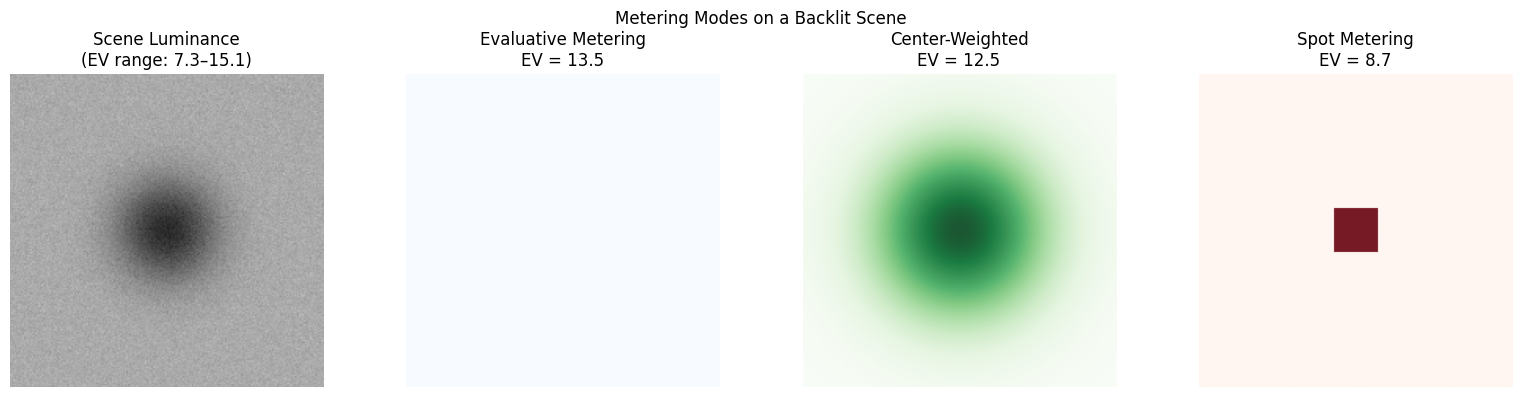


Insight: On a backlit scene, evaluative metering overexposes (pulled by bright BG).
Spot metering on the subject gives the most accurate reading for the subject.


In [49]:
scene_map = simulate_scene('backlit', size=(200, 200))
H, W = scene_map.shape

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Metering Modes on a Backlit Scene')

axes[0].imshow(scene_map, cmap='gray', vmin=6, vmax=18)
axes[0].set_title(f'Scene Luminance\n(EV range: {scene_map.min():.1f}–{scene_map.max():.1f})')
axes[0].axis('off')

ev_eval = meter_scene(scene_map, 'evaluative')
weight_eval = np.ones_like(scene_map) / scene_map.size
axes[1].imshow(weight_eval, cmap='Blues', alpha=0.9)
axes[1].set_title(f'Evaluative Metering\nEV = {ev_eval:.1f}')
axes[1].axis('off')

ev_cw = meter_scene(scene_map, 'center_weighted')
weight_cw = gaussian_weight_map(scene_map.shape)
axes[2].imshow(weight_cw, cmap='Greens', alpha=0.9)
axes[2].set_title(f'Center-Weighted\nEV = {ev_cw:.1f}')
axes[2].axis('off')

ev_spot = meter_scene(scene_map, 'spot')
weight_spot = np.zeros_like(scene_map, dtype=float)
r = max(H, W) // 14
weight_spot[H//2-r:H//2+r, W//2-r:W//2+r] = 1.0
axes[3].imshow(weight_spot, cmap='Reds', alpha=0.9)
axes[3].set_title(f'Spot Metering\nEV = {ev_spot:.1f}')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print("\nInsight: On a backlit scene, evaluative metering overexposes (pulled by bright BG).")
print("Spot metering on the subject gives the most accurate reading for the subject.")

*Illustrate the 18% gray standard statistically*
- Distribution of arithmetic vs geometric means
- Histogram of a single scene — showing where 18% gray falls

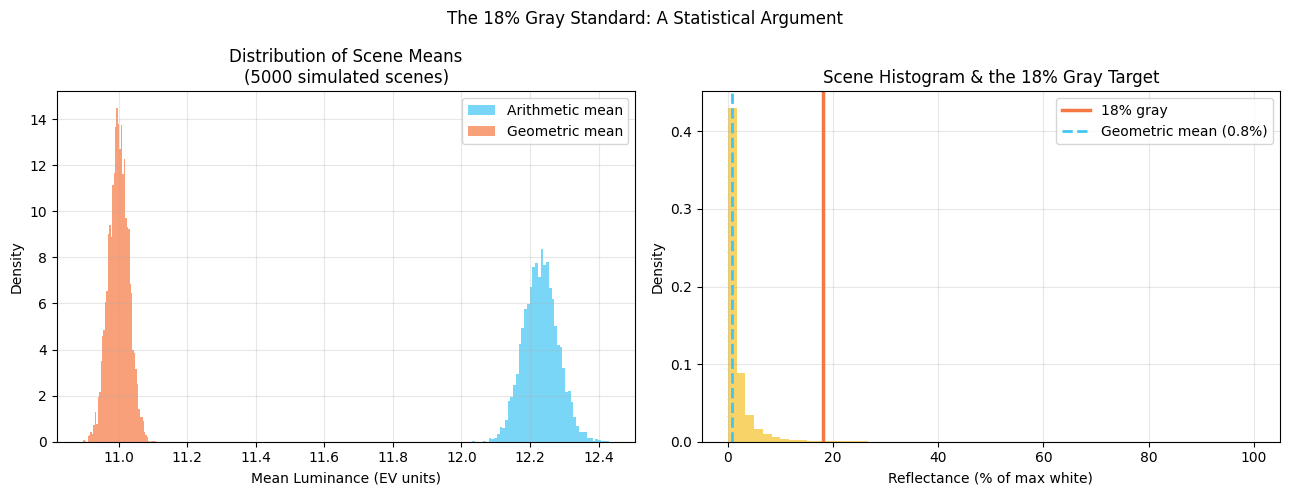

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('The 18% Gray Standard: A Statistical Argument')

n_scenes = 5000
scene_means = []
scene_geo_means = []

for _ in range(n_scenes):
    scene = simulate_scene('mixed', size=(50, 50))
    luminance_linear = 2 ** scene
    scene_means.append(np.mean(luminance_linear))
    scene_geo_means.append(np.exp(np.mean(np.log(luminance_linear))))

axes[0].hist(np.log2(scene_means), bins=50, alpha=0.7, color=TEAL, label='Arithmetic mean', density=True)
axes[0].hist(np.log2(scene_geo_means), bins=50, alpha=0.7, color=CORAL, label='Geometric mean', density=True)
axes[0].set_xlabel('Mean Luminance (EV units)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Scene Means\n(5000 simulated scenes)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

scene = simulate_scene('mixed', size=(200, 200))
luminance_linear = 2 ** scene
max_lum = luminance_linear.max()
reflectance = luminance_linear / max_lum * 100

axes[1].hist(reflectance.ravel(), bins=60, color=GOLD, alpha=0.8, density=True)
axes[1].axvline(x=18, color=CORAL, linewidth=2.5, label='18% gray')
geo_mean_ref = np.exp(np.mean(np.log(reflectance.ravel())))
axes[1].axvline(x=geo_mean_ref, color=TEAL, linewidth=2, linestyle='--', label=f'Geometric mean ({geo_mean_ref:.1f}%)')
axes[1].set_xlabel('Reflectance (% of max white)')
axes[1].set_ylabel('Density')
axes[1].set_title('Scene Histogram & the 18% Gray Target')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary & Conclusions

What started as a simple question — *why does the f-stop sequence use these specific numbers?* — turned out to be a gateway into four distinct areas of mathematics:

**Geometry & Algebra** revealed that the $\sqrt{2}$ progression is not arbitrary — it's the only sequence that doubles the aperture area (and thus light) with each step. Every camera dial in the world encodes this single geometric truth.

**Linear Algebra** showed that the exposure triangle, when expressed in log-space (EV units), becomes a linear equation. All valid exposure combinations for a given EV lie on a hyperplane — an infinite family of solutions connected by simple linear relationships.

**Calculus** let us frame exposure as a continuous optimization problem, define a cost function encoding creative preferences and physical constraints, and find the optimal settings using gradient descent — the same algorithm that trains neural networks.

**Probability & Statistics** explained why cameras are calibrated to 18% gray: it corresponds to the geometric mean of a log-normal luminance distribution typical of natural scenes. Different metering modes are simply different statistical estimators applied to the pixel luminance distribution.

### Key Takeaways
- Every f-stop doubles or halves light: $A \propto D^2 \implies \Delta D = \sqrt{2}$ per stop
- EV is a log₂ transform of exposure: $EV = 2\log_2(N) - \log_2(t) - \log_2(S/100)$
- The exposure triangle is a hyperplane in log-space — infinitely many valid solutions per EV
- Cameras meter for the geometric mean (18% gray) of a log-normal scene distribution
- Optimal settings can be found by constrained gradient descent in three-dimensional log-space

### Further Directions
- Extend the optimizer to include **lens diffraction limits** (sharpness degrades at very small apertures)
- Model **reciprocity failure** in film photography (long exposures need extra time)
- Apply **Bayesian inference** to update exposure estimates from partial scene information
- Implement a **real-time exposure advisor** using a webcam histogram as input